In [1]:
%pip install opencv-python, opencv-contrib-python

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'opencv-python,': Expected semicolon (after name with no version specifier) or end
    opencv-python,
                 ^


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:

img = cv2.imread('data_img/orig.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rows, cols, dim = img.shape

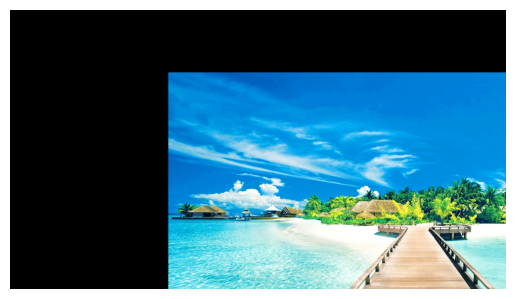

In [13]:
# a_13 на сколько передвинуть по x
# a_23 на сколько передвинуть по y
M = np.float32([ [1, 0, 817],
                [0, 1, 322],
                [0, 0, 1] ])
# Перспективное преобразование
translated_img = cv2.warpPerspective(img_rgb, M, (cols, rows))
plt.axis('off')
plt.imshow(translated_img)
plt.show()

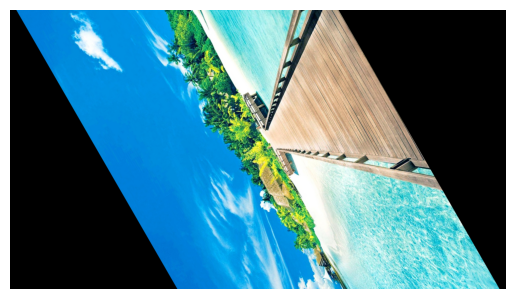

In [17]:
# центр, угол, коэф. масштаба
r_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), 120, 1)

img_rotation = cv2.warpAffine(img_rgb, r_matrix, (cols, rows))

plt.axis('off')
plt.imshow(img_rotation)
plt.show()

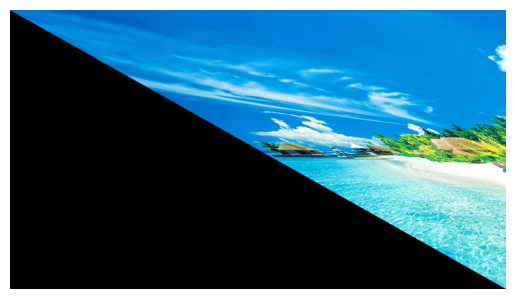

In [21]:
rows, cols = img.shape[:2]
src_points = np.float32([[0,0], [cols - 1,0], [0,rows - 1]])
dst_points = np.float32( [[0,0], [int(cols-1),0], [int(cols-1),rows - 1]])
affine_matrix = cv2.getAffineTransform(src_points, dst_points)
img_output = cv2.warpAffine(img_rgb, affine_matrix, (cols,rows))

plt.axis('off')
plt.imshow(img_output)
plt.show()


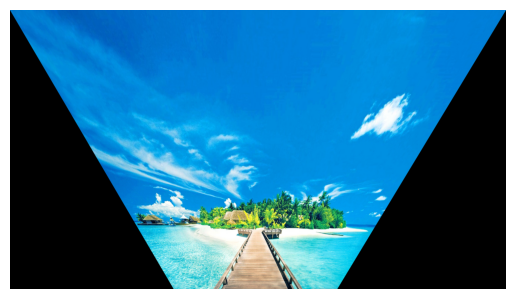

In [22]:
src_points = np.float32([[0,0], [cols-1,0], [0,rows-1], [cols-1,rows-1]])
dst_points = np.float32([[0,0], [cols-1,0], [int(0.33*cols),rows-1], 
[int(0.66*cols),rows-1]])
projective_matrix = cv2.getPerspectiveTransform(src_points, dst_points)
img_output = cv2.warpPerspective(img_rgb, projective_matrix, (cols,rows))

plt.axis('off')
plt.imshow(img_output)
plt.show()

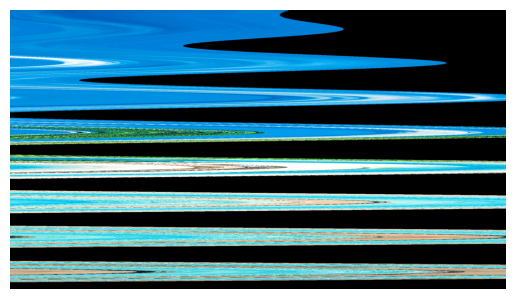

In [39]:
img_output = np.zeros(img_rgb.shape, dtype=img_rgb.dtype)
for i in range(rows):
    am = 30 * i/10
    for j in range(cols):
        offset_x = int(am * math.cos(2*math.pi*i/180))
        offset_y = 0
        if j+offset_x < rows:
            img_output[i,j] = img_rgb[i,(j+offset_x)%cols]
        else:
            img_output[i,j] = 0

plt.axis('off')
plt.imshow(img_output)
plt.show()


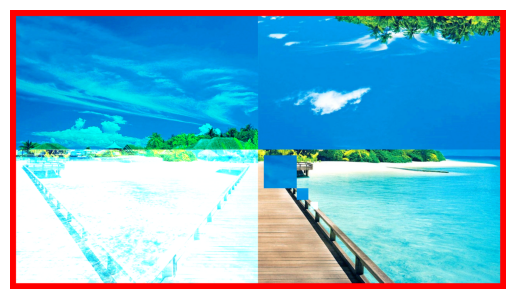

In [69]:
h_rows, h_cols = rows // 2, cols // 2

# Верхняя левая
part1 = img_rgb[0:h_rows, 0:h_cols].copy()
# Верхняя правая
part2 = img_rgb[0:h_rows, h_cols:cols].copy()
# Нижняя левая
part3 = img_rgb[h_rows:rows, 0:h_cols].copy()
# Ннижняя правая
part4 = img_rgb[h_rows:rows, h_cols:cols].copy()

# Обнуление красного
part1_copy = part1.copy()
part1_copy[:,:, 0] = 0

# Поворот part2 два раза по 90
part2_copy = np.rot90(part2, 2)

part3_copy = np.zeros_like(part3)
for c in range(3):
    part3_copy[:, :, c] = np.clip(
        part3[:, :, c].astype(np.int32) + part4[:, :, c].astype(np.int32), 0, 255
    ).astype(np.uint8)

part4_copy = part4.copy()

fragment1 = part1_copy[30:200, 30:200].copy()
part4_copy[30:200, 30:200] = fragment1

fragment2 = part2_copy[200:260, 200:260].copy()
part4_copy[200:260, 200:260] = fragment2

fragment3 = part3_copy[270:310, 270:310].copy()
part4_copy[270:310, 270:310] = fragment3


img_result = np.zeros_like(img_rgb)
img_result[0:h_rows, 0:h_cols] = part1_copy
img_result[0:h_rows, h_cols:cols] = part2_copy
img_result[h_rows:rows, 0:h_cols] = part3_copy
img_result[h_rows:rows, h_cols:cols] = part4_copy

for i in range(31):
    img_result[i, :] = [255, 0, 0]
    img_result[:, i] = [255, 0, 0]
    img_result[rows-30:rows, :] = [255, 0, 0]
    img_result[:, cols-30:cols] = [255, 0, 0]

plt.imshow(img_result)
plt.axis('off')
plt.show()

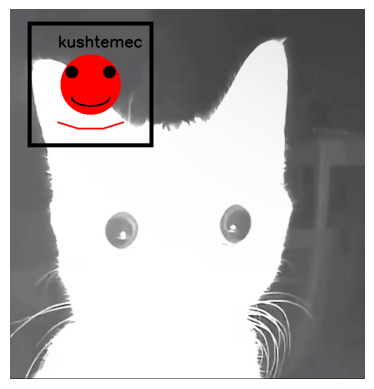

True

In [9]:
def remove(background, foreground, pos_x=70, pos_y=50):
    h, w = foreground.shape[:2]
    roi = background[pos_y:pos_y+h, pos_x:pos_x+w]

    gray = cv2.cvtColor(foreground, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    mask_inv = cv2.bitwise_not(mask)
    
    bg_cleared = cv2.bitwise_and(roi, roi, mask=mask)
    fg = cv2.bitwise_and(foreground, foreground, mask=mask_inv)
    result = cv2.add(bg_cleared, fg)
    
    background[pos_y:pos_y+h, pos_x:pos_x+w] = result
    return background

char = np.full((500, 500, 3), (255, 255, 255), dtype=np.uint8)
# Made rectangle larger (thicker border)
cv2.rectangle(char, (0,0), (499,499), (0,0,0), 30)  # Increased from 5 to 15
# Made main circle smaller (radius reduced from 175 to 120)
cv2.circle(char, (250,250), 120, (0,0,255), -1)  # Changed from 175 to 120
cv2.circle(char, (175,200), 25, (0,0,0), -1)
cv2.circle(char, (325,200), 25, (0,0,0), -1)
cv2.ellipse(char, (250,300), (75,35), 0, 0, 180, (0,0,0), 5)
pts = np.array([[120,400], [200,425], [300,425], [380,400]], np.int32)
cv2.polylines(char, [pts], False, (0,0,255), 5)
cv2.putText(char, 'kushtemec', (120,100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 5)

bg = cv2.imread('data_img/cat.jpg')

result = remove(bg, char)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

cv2.imwrite('data_img/kushtemec.jpg', result)